In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings 
warnings.filterwarnings("ignore")

In [7]:
df = pd.read_csv(r'IPL.csv')
df.head()

,match_id,date,venue,team1,team2,stage,toss_winner,toss_decision,first_ings_score,first_ings_wkts,second_ings_score,second_ings_wkts,match_winner,won_by,margin,player_of_the_match,top_scorer,highscore,best_bowling,best_bowling_figure
0,1,"March 26,2022","Wankhede Stadium, Mumbai",Chennai,Kolkata,Group,Kolkata,Field,131,5,133,4,Kolkata,Wickets,6,Umesh Yadav,MS Dhoni,50,Dwayne Bravo,3--20
1,2,"March 27,2022","Brabourne Stadium, Mumbai",Delhi,Mumbai,Group,Delhi,Field,177,5,179,6,Delhi,Wickets,4,Kuldeep Yadav,Ishan Kishan,81,Kuldeep Yadav,3--18
2,3,"March 27,2022","Dr DY Patil Sports Academy, Mumbai",Banglore,Punjab,Group,Punjab,Field,205,2,208,5,Punjab,Wickets,5,Odean Smith,Faf du Plessis,88,Mohammed Siraj,2--59
3,4,"March 28,2022","Wankhede Stadium, Mumbai",Gujarat,Lucknow,Group,Gujarat,Field,158,6,161,5,Gujarat,Wickets,5,Mohammed Shami,Deepak Hooda,55,Mohammed Shami,3--25
4,5,"March 29,2022","Maharashtra Cricket Association Stadium,Pune",Hyderabad,Rajasthan,Group,Hyderabad,Field,210,6,149,7,Rajasthan,Runs,61,Sanju Samson,Aiden Markram,57,Yuzvendra Chahal,3--22


Basic Information

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74 entries, 0 to 73
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   match_id             74 non-null     int64 
 1   date                 74 non-null     object
 2   venue                74 non-null     object
 3   team1                74 non-null     object
 4   team2                74 non-null     object
 5   stage                74 non-null     object
 6   toss_winner          74 non-null     object
 7   toss_decision        74 non-null     object
 8   first_ings_score     74 non-null     int64 
 9   first_ings_wkts      74 non-null     int64 
 10  second_ings_score    74 non-null     int64 
 11  second_ings_wkts     74 non-null     int64 
 12  match_winner         74 non-null     object
 13  won_by               74 non-null     object
 14  margin               74 non-null     int64 
 15  player_of_the_match  74 non-null     object
 16  top_scorer

In [9]:
df.describe()

,match_id,first_ings_score,first_ings_wkts,second_ings_score,second_ings_wkts,margin,highscore
count,74.000000,74.000000,74.000000,74.000000,74.000000,74.000000,74.000000
mean,37.500000,171.121622,6.135135,158.540541,6.175676,16.972973,71.716216
std,21.505813,29.048355,2.222699,29.299207,2.639832,19.651047,20.705052
min,1.000000,68.000000,0.000000,72.000000,1.000000,2.000000,28.000000
25%,19.250000,154.250000,5.000000,142.750000,4.000000,5.250000,57.000000
50%,37.500000,169.500000,6.000000,160.000000,6.000000,8.000000,68.000000
75%,55.750000,192.750000,8.000000,176.000000,8.000000,18.000000,87.750000
max,74.000000,222.000000,10.000000,211.000000,10.000000,91.000000,140.000000


Check size of rows and columns of the dataset

In [21]:
print(f"Total rows of dataset are: {df.shape[0]} and total columns are: {df.shape[1]}")

Total rows of dataset are: 74 and total columns are: 20


How many columns have null values in total

In [29]:
df.isna().sum()

match_id               0
date                   0
venue                  0
team1                  0
team2                  0
stage                  0
toss_winner            0
toss_decision          0
first_ings_score       0
first_ings_wkts        0
second_ings_score      0
second_ings_wkts       0
match_winner           0
won_by                 0
margin                 0
player_of_the_match    0
top_scorer             0
highscore              0
best_bowling           0
best_bowling_figure    0
dtype: int64

1. Which team won most matches?

Text(0.5, 1.0, 'Number of match win by a teams')

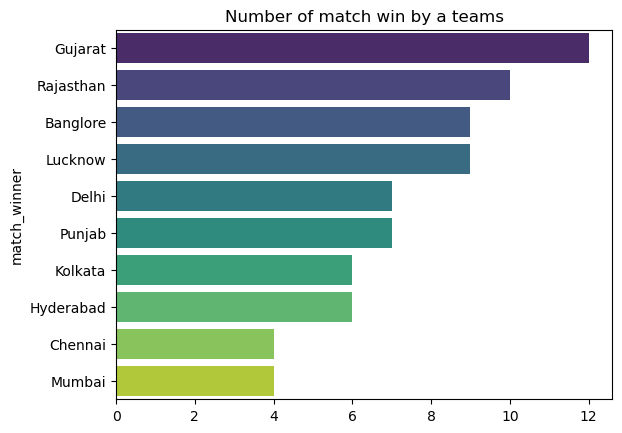

In [53]:
match_wins = df['match_winner'].value_counts()
sns.barplot(y = match_wins.index, x = match_wins.values, palette = 'viridis')
plt.title("Number of match win by a teams")

2. Toss Decision Trends

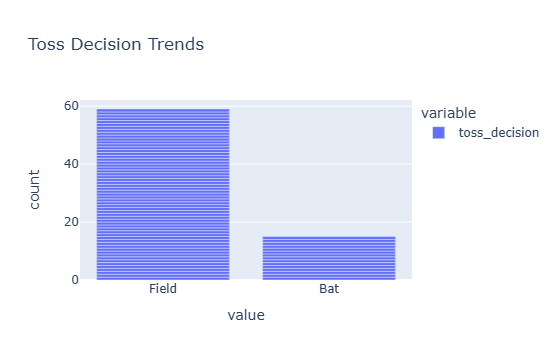

In [73]:
#sns.countplot(x= df['toss_decision'], palette = 'rainbow')
toss = df['toss_decision']
px.bar(toss, title = "Toss Decision Trends")


3. Toss winner vs Match winner

In [92]:
count = df[df['toss_winner'] == df['match_winner']]['match_id'].count()
percentage = (count * 100)/df.shape[0]
percentage.round(2)

np.float64(48.65)

How do team wins (By Runs or Wickets)?


Text(0.5, 1.0, 'Matches won by')

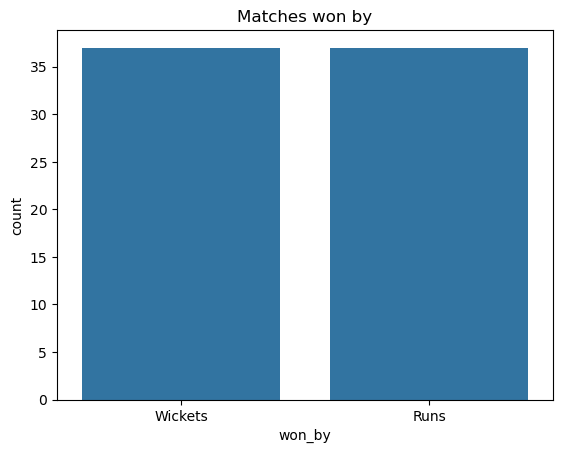

In [103]:
sns.countplot(x = df['won_by'])
plt.title("Matches won by")
#px.bar(x = df['won_by'], title = "Matches won By")

KEY PLAYER PERFORMANCES

1. Most "player of the Match " Awards

In [125]:
player_of_the_match = df['player_of_the_match'].value_counts()
count = player_of_the_match.head(10)
count

player_of_the_match
Kuldeep Yadav      4
Jos Buttler        3
Umesh Yadav        2
Quinton de Kock    2
David Miller       2
Umran Malik        2
K L Rahul          2
Rahul Tripathi     2
Hardik Pandya      2
Jasprit Bumrah     2
Name: count, dtype: int64

Text(0.5, 1.0, 'Top 10 player of the Match')

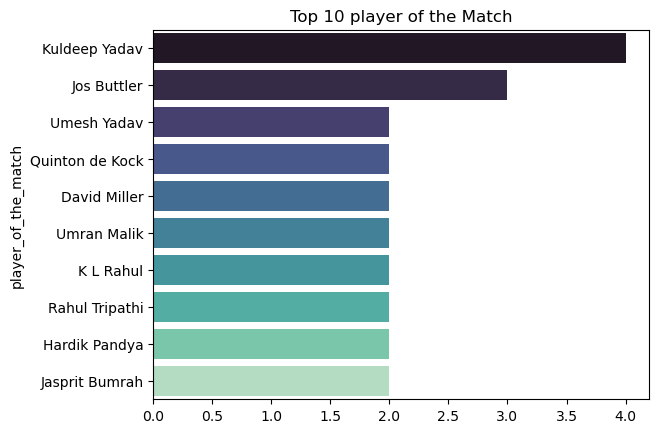

In [131]:
sns.barplot(y = count.index, x = count.values, palette = 'mako')
plt.title("Top 10 player of the Match")

2. Top Scorers

In [152]:
high = df.groupby('top_scorer')['highscore'].sum().sort_values(ascending = False).head(2)
#high.nlargest(2)
high

top_scorer
Jos Buttler        651
Quinton de Kock    377
Name: highscore, dtype: int64

<Axes: xlabel='top_scorer'>

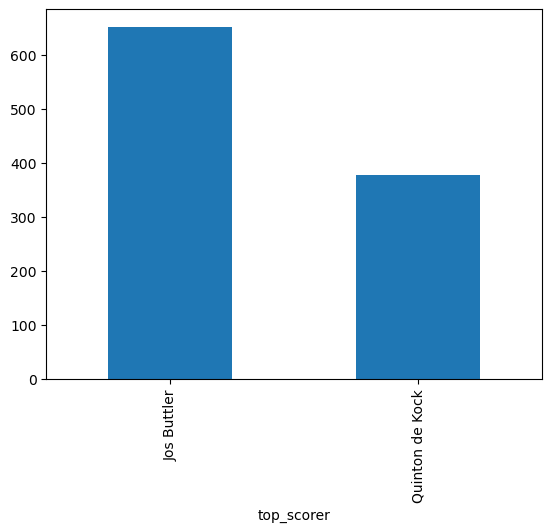

In [156]:
high.plot(kind='bar')

3. 10 Best Bowling figures

In [179]:
df['highest_wickets'] = df['best_bowling_figure'].apply(lambda x: x.split("--")[0])
df['highest_wickets'] = df['highest_wickets'].astype(int)

In [183]:
top_bowler = df.groupby('best_bowling')['highest_wickets'].sum().sort_values(ascending = False).head(10)

Text(0.5, 1.0, 'Top 10 Bowlers')

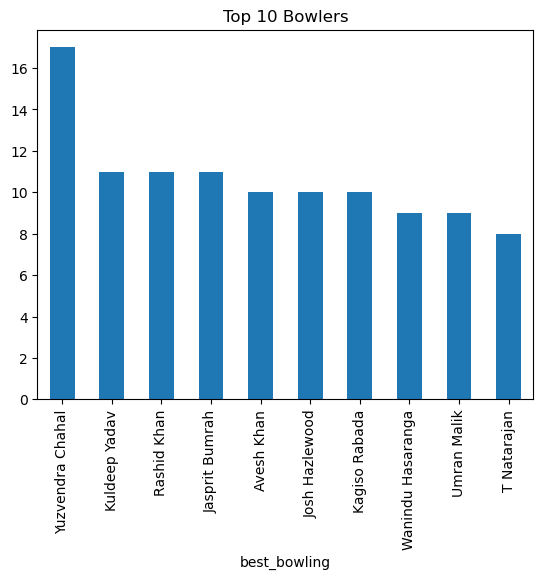

In [185]:
top_bowler.plot(kind='bar')
plt.title("Top 10 Bowlers")

VENUE ANALYSIS

1. Most matches played by venue

In [202]:
venue_count = df['venue'].value_counts()
venue_count

venue
Wankhede Stadium, Mumbai                        21
Dr DY Patil Sports Academy, Mumbai              20
Brabourne Stadium, Mumbai                       16
Maharashtra Cricket Association Stadium,Pune    13
Eden Gardens, Kolkata                            2
Narendra Modi Stadium, Ahmedabad                 2
Name: count, dtype: int64

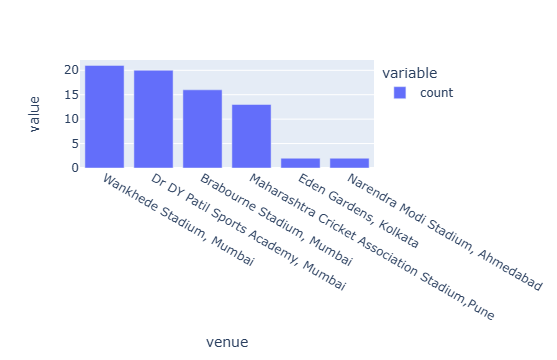

In [203]:
px.bar(venue_count)

<Axes: ylabel='venue'>

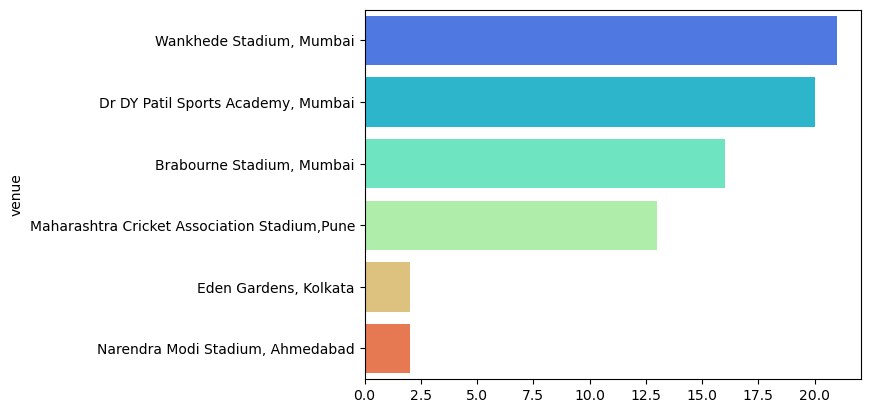

In [210]:
sns.barplot(y = venue_count.index, x = venue_count.values, palette = 'rainbow')

CUSTOM QUESTIONS AND INSIGHTS

1. Who won the highest margin by run?

In [217]:
df[df['won_by'] == "Runs"].sort_values(by = 'margin', ascending = False).head(1)[['match_winner','margin']]

,match_winner,margin
54,Chennai,91


2. Which player had the highest individual score?

In [220]:
df[df['highscore'] == df['highscore'].max()][['top_scorer','highscore']]

,top_scorer,highscore
65,Quinton de Kock,140


3. Which bowler had the best bowling figure?

In [223]:
df[df['highest_wickets'] == df['highest_wickets'].max()][['best_bowling','best_bowling_figure']]

,best_bowling,best_bowling_figure
29,Yuzvendra Chahal,5--40
39,Umran Malik,5--25
53,Wanindu Hasaranga,5--18
55,Jasprit Bumrah,5--10
